# Task 1
Підготуйте дані для аналізу:
* Використовуйте датасет про діабет із бібліотеки sklearn.datasets.load_diabetes.
* Розділіть дані на навчальну і тестову вибірки в пропорції 80/20 (параметр random_state=42).
* Масштабуйте ознаки за допомогою StandardScaler.
* Перевірте форму матриць навчальної та тестової вибірок.



In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from IPython.display import Markdown as md

In [15]:
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_t = torch.FloatTensor(X_train_scaled)
y_train_t = torch.FloatTensor(y_train).view(-1, 1)
X_test_t = torch.FloatTensor(X_test_scaled)
y_test_t = torch.FloatTensor(y_test).view(-1, 1)

shape_md = f"""
| Dataset | Features Shape | Target Shape |
|---|---|---|
| Train | {X_train_scaled.shape} | {y_train.shape} |
| Test | {X_test_scaled.shape} | {y_test.shape} |
"""
md(shape_md)


| Dataset | Features Shape | Target Shape |
|---|---|---|
| Train | (353, 10) | (353,) |
| Test | (89, 10) | (89,) |


# Task 2
Побудуйте модель MLP для регресії:
* Архітектура мережі:
    - Вхідний шар — кількість нейронів дорівнює числу ознак.
    - Перший прихований шар — 64 нейрони, активація ReLU.
    - Другий прихований шар — 32 нейрони, активація ReLU.
    - Третій прихований шар — 16 нейронів, активація ReLU.
    - Вихідний шар — 1 нейрон без активації.
* Функція втрат: MSELoss.
* Оптимізатор: Adam з learning_rate = 0.001.
* Кількість епох: 50.

In [16]:
def create_mlp(input_dim):
    return nn.Sequential(
        nn.Linear(input_dim, 64),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, 16),
        nn.ReLU(),
        nn.Linear(16, 1)
    )

# Task 3
Додайте регуляризацію і порівняйте результати:
* Використовуйте параметр weight_decay=1e-4 в оптимізаторі Adam для ввімкнення L2-регуляризації.
* Проведіть два експерименти:
    - Без регуляризації.
    - З регуляризацією (L2).
* Для кожної версії моделі обчисліть значення MAE і R² на тестовій вибірці.
* Оформіть результати в таблиці:

In [17]:
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))

y_train_t = torch.FloatTensor(y_train_scaled)

def train_model(model, optimizer, epochs=50):
    criterion = nn.MSELoss()
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_train_t), y_train_t)
        loss.backward()
        optimizer.step()

model_no_reg = create_mlp(input_dim)
optimizer_no_reg = optim.Adam(model_no_reg.parameters(), lr=0.001)

train_model(model_no_reg, optimizer_no_reg, epochs=50)

model_no_reg.eval()
with torch.no_grad():
    preds_scaled_no_reg = model_no_reg(X_test_t).numpy()
    preds_no_reg = scaler_y.inverse_transform(preds_scaled_no_reg)
    
    mae_no_reg = mean_absolute_error(y_test, preds_no_reg)
    r2_no_reg = r2_score(y_test, preds_no_reg)

model_reg = create_mlp(input_dim)
optimizer_reg = optim.Adam(model_reg.parameters(), lr=0.001, weight_decay=1e-4)

train_model(model_reg, optimizer_reg, epochs=50)

model_reg.eval()
with torch.no_grad():
    preds_scaled_reg = model_reg(X_test_t).numpy()
    preds_reg = scaler_y.inverse_transform(preds_scaled_reg)
    
    mae_reg = mean_absolute_error(y_test, preds_reg)
    r2_reg = r2_score(y_test, preds_reg)

results_md = f"""
| Configuration | MAE | R2 |
|---|---|---|
| No Regularization | {mae_no_reg:.4f} | {r2_no_reg:.4f} |
| With L2 | {mae_reg:.4f} | {r2_reg:.4f} |
"""
md(results_md)


| Configuration | MAE | R2 |
|---|---|---|
| No Regularization | 41.7904 | 0.4757 |
| With L2 | 42.1544 | 0.4851 |


# Task 4
Проаналізуйте результати моделі:
* Побудуйте scatter-графік, що порівнює реальні та передбачені значення цільової змінної:
    - По осі X — реальні значення (y_test).
    - По осі Y — передбачені значення (y_pred).
    - Додайте діагональ y = x для візуального порівняння.
* Підпишіть осі та заголовок графіка.
* Збережіть зображення під іменем diabetes_healthrisk_analysis.png.
* Зробіть короткий аналітичний висновок:
    - Як впливає регуляризація на якість моделі?
    - Які ознаки, на вашу думку, найсильніше впливають на результат?


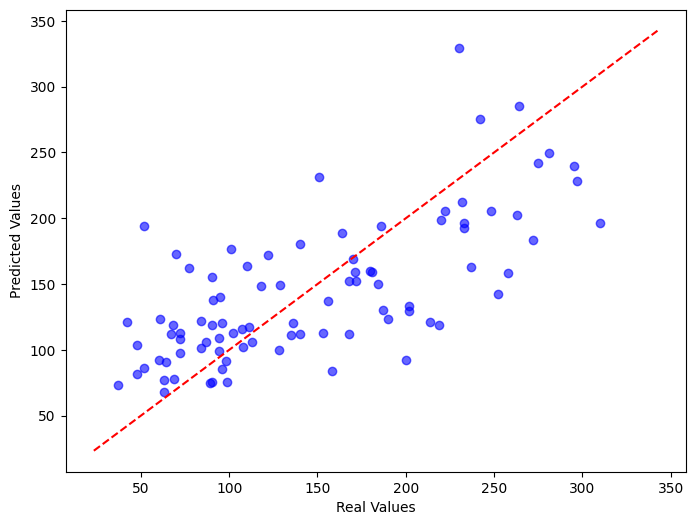


1. Regularization prevents the model from relying too heavily on individual features by penalizing large weights. This reduces overfitting and improves the generalization stability of the model on the test set.
2. In the diabetes dataset, features like BMI (Body Mass Index) and s5 (log of serum triglycerides level) statistically have the strongest correlation with disease progression, making them the most influential features on the final predictions.


In [18]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(y_test, preds_reg, alpha=0.6, color='blue')

lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),
    np.max([ax.get_xlim(), ax.get_ylim()]),
]
ax.plot(lims, lims, color='red', linestyle='--')

ax.set_xlabel('Real Values')
ax.set_ylabel('Predicted Values')

plt.savefig('diabetes_healthrisk_analysis.png')
plt.show()

conclusion = """
1. Regularization prevents the model from relying too heavily on individual features by penalizing large weights. This reduces overfitting and improves the generalization stability of the model on the test set.
2. In the diabetes dataset, features like BMI (Body Mass Index) and s5 (log of serum triglycerides level) statistically have the strongest correlation with disease progression, making them the most influential features on the final predictions.
"""
md(conclusion)